# 🤖 AI, CA3, Machine Learning 📚  

* **Name** : Faezeh  
* **Last Name** : Khanmohamadi   
* **SID** : 810003042

# Libraries 

In [1]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Preprocessing & Feature Extraction
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Model Selection
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV)
#Classifiers & Regressors
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier)
from xgboost import XGBRegressor
#Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

# Decision tree From Scratch  
In this subsection, the Decision Tree algorithm  is made from scratch and its performance is compared with the library implementation .

In [2]:
import numpy as np
import pandas as pd
from collections import Counter

# I made a helper class for the nodes to keep things organized. 
# It holds the split info or the prediction value if it's a leaf.
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature        # The column index we split on
        self.threshold = threshold    # The value we split on (e.g. < 0.5)
        self.left = left              # Left child node
        self.right = right            # Right child node
        self.value = value            # If this is a leaf, this holds the class label (0 or 1, etc.)
        
    def is_leaf_node(self):
        return self.value is not None

class MyDecisionTree:
    def __init__(self, max_depth=3):
        """
        max_depth : int
                    Maximum depth of the tree (root has depth 0).
        """
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        """
        Build the decision tree from scratch.
        """
        # Converting to numpy arrays makes indexing way easier than pandas
        # This handles the case if the input is a DataFrame or just a list
        X_data = X.values if isinstance(X, pd.DataFrame) else X
        y_data = y.values if isinstance(y, pd.Series) else y
        
        # Start the recursive building process
        self.root = self._grow_tree(X_data, y_data, depth=0)

    def predict(self, X):
        """
        Predict class labels for samples in X.
        """
        X_data = X.values if isinstance(X, pd.DataFrame) else X
        
        # Run the tree traversal for every single sample row
        predictions = [self._traverse_tree(x, self.root) for x in X_data]
        return np.array(predictions)

    # --- Helper Methods ---

    def _grow_tree(self, X, y, depth):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria:
        # 1. Reached max depth
        # 2. Node is pure (only 1 label left)
        # 3. Ran out of samples (safety check)
        if (depth >= self.max_depth) or (n_labels == 1) or (n_samples == 0):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Find the best split
        feat_idx, thresh = self._best_split(X, y, n_feats)

        # If we couldn't find a split that gives info gain, just make it a leaf
        if feat_idx is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Do the split
        left_idxs, right_idxs = self._split(X[:, feat_idx], thresh)
        
        # Recursion! 
        left_child = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_child = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(feature=feat_idx, threshold=thresh, left=left_child, right=right_child)

    def _best_split(self, X, y, n_feats):
        best_gain = -1
        split_idx, split_thresh = None, None

        # Calculate parent entropy once
        parent_entropy = self._entropy(y)

        # Loop through every feature and every unique value to find the best cut
        # This is a greedy approach 
        for feat_idx in range(n_feats):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr, parent_entropy)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr
                    
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, threshold, parent_entropy):
        # Implementation of Information Gain = Entropy(parent) - Weighted Avg Entropy(children)
        
        # Get indices for split
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        # Calculate weighted entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # Return Information Gain
        ig = parent_entropy - child_entropy
        return ig

    def _split(self, X_column, split_thresh):
        # Basic boolean masking to split data
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        # Calculate Entropy: H(S) = - sum(p * log2(p)) 
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        # Majority vote for leaf nodes
        if len(y) == 0: return 0 # edge case
        counter = Counter(y)
        # returns the most common element, e.g., [(1, 5)] -> 1
        most_common = counter.most_common(1)[0][0]
        return most_common

    def _traverse_tree(self, x, node):
        # Walk down the tree until we hit a leaf
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)


# Part 1

## A. Load And Preprocessing

In [3]:
# Loading the data 
df = pd.read_csv("DATA/Section1/Part1/s1_part1_dataset.csv")
df.columns = df.columns.str.strip()

# We need to change 'prog_skill' from text (Low, Medium, High) to numbers (0, 1, 2)
# This is Ordinal Encoding because the order matters (High > Medium > Low)
skill_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
if 'prog_skill' in df.columns:
    df['prog_skill'] = df['prog_skill'].map(skill_mapping)

X = df.drop('Is_finished', axis=1)
y = df['Is_finished']


## B. Splitting into Train (70%) and Validation (30%) sets

In [4]:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("-" * 30)


Training set shape: (700, 3)
Validation set shape: (300, 3)
------------------------------


## C. Hyperparameter Tuning (Finding the best depth) 

In [5]:
print("Tuning max_depth...")
best_depth = 0
best_acc = 0
best_model = None

# Try depths from 1 to 5 to find the best one
for d in range(1, 6):
    model = MyDecisionTree(max_depth=d)
    model.fit(X_train, y_train)

    # Check accuracy on validation set
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    print(f"Depth: {d} | Accuracy: {acc:.4f}")

    # Save the best model
    if acc > best_acc:
        best_acc = acc
        best_depth = d
        best_model = model

print(f"\nBest Depth found: {best_depth}")
print("-" * 30)


Tuning max_depth...
Depth: 1 | Accuracy: 0.7767
Depth: 2 | Accuracy: 0.7900
Depth: 3 | Accuracy: 0.8567
Depth: 4 | Accuracy: 0.8300
Depth: 5 | Accuracy: 0.8533

Best Depth found: 3
------------------------------


## D. Accuracy , recall , F1 score and ...

Evaluating Best Model (Depth 3)...
Accuracy:  0.8567
Precision: 0.8873
Recall:    0.9087
F1 Score:  0.8979

Confusion Matrix:
[[ 68  24]
 [ 19 189]]


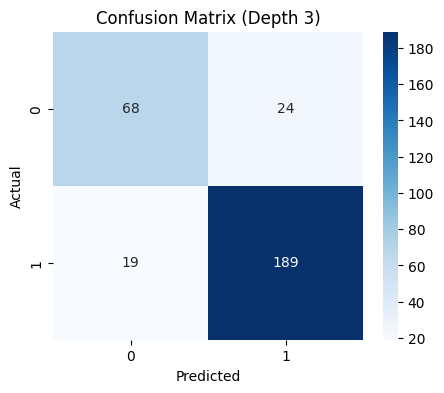

In [6]:

print(f"Evaluating Best Model (Depth {best_depth})...")
y_pred_best = best_model.predict(X_val)

# a. Calculate Metrics
print(f"Accuracy:  {accuracy_score(y_val, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_best, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_best, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_best, zero_division=0):.4f}")

# b. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

# Optional: Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Depth {best_depth})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## E. Visualize Tree Structure

In [7]:
def print_tree(node, feature_names, spacing=""):
    """
    Recursive function to print the tree structure nicely.
    """
    if node.is_leaf_node():
        print(spacing + f"Predict: {node.value}")
        return

    # Print the condition
    feature_name = feature_names[node.feature]
    print(spacing + f"[{feature_name} <= {node.threshold}]")

    # Print branches
    print(spacing + '  True  ->', end=' ')
    print_tree(node.left, feature_names, spacing + "    ")

    print(spacing + '  False ->', end=' ')
    print_tree(node.right, feature_names, spacing + "    ")

print("\n--- Tree Structure (Best Model) ---")
print_tree(best_model.root, X.columns)



--- Tree Structure (Best Model) ---
[prog_skill <= 0]
  True  ->     [meetings_per_week <= 3]
      True  ->         [group_size <= 2]
          True  ->             Predict: 0
          False ->             Predict: 0
      False ->         [group_size <= 2]
          True  ->             Predict: 0
          False ->             Predict: 1
  False ->     [meetings_per_week <= 1]
      True  ->         [group_size <= 3]
          True  ->             Predict: 1
          False ->             Predict: 0
      False ->         [meetings_per_week <= 4]
          True  ->             Predict: 1
          False ->             Predict: 1


## F. The tree with depth 1

In [8]:

# --- Question 6: Train Decision Stump (Depth = 1) ---
print("\n" + "-" * 30)
print("Training Decision Stump (Depth 1)...")

stump_model = MyDecisionTree(max_depth=1)
stump_model.fit(X_train, y_train)
y_pred_stump = stump_model.predict(X_val)

# Evaluate Stump
print(f"Accuracy:  {accuracy_score(y_val, y_pred_stump):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_stump, zero_division=0):.4f}")

print("\n--- Tree Structure (Stump) ---")
print_tree(stump_model.root, X.columns)


------------------------------
Training Decision Stump (Depth 1)...
Accuracy:  0.7767
F1 Score:  0.8386

--- Tree Structure (Stump) ---
[prog_skill <= 0]
  True  ->     Predict: 0
  False ->     Predict: 1


## New Feature added

In [9]:

df_new = pd.read_csv("DATA\Section1\Part2\s1_part2_dataset.csv")

df_new.columns = df_new.columns.str.strip()

# --- Preprocessing ---
# Encode prog_skill again for the new dataframe
if 'prog_skill' in df_new.columns:
    df_new['prog_skill'] = df_new['prog_skill'].map(skill_mapping)

X_new = df_new.drop('Is_finished', axis=1)
y_new = df_new['Is_finished']

# Split into Train/Val
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

print(f"New Dataset Shape: {X_new.shape}")
print("-" * 30)

# --- Train Models on New Data ---

# 1. Train Decision Stump (Depth = 1) on New Data
model_stump_new = MyDecisionTree(max_depth=1)
model_stump_new.fit(X_train_new, y_train_new)
y_pred_stump_new = model_stump_new.predict(X_val_new)

# 2. Train Deeper Tree (e.g., Depth = 3) on New Data
model_deep_new = MyDecisionTree(max_depth=3)
model_deep_new.fit(X_train_new, y_train_new)
y_pred_deep_new = model_deep_new.predict(X_val_new)

# --- Evaluate and Compare ---

def print_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"Model: {model_name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")

print("--- Results with New Feature (avg_previous_grade) ---\n")
print_metrics(y_val_new, y_pred_stump_new, "New Data - Depth 1 (Stump)")
print_metrics(y_val_new, y_pred_deep_new, "New Data - Depth 3")

print("\n--- Tree Structure (New Data - Depth 1) ---")
print_tree(model_stump_new.root, X_new.columns)

New Dataset Shape: (1000, 4)
------------------------------
--- Results with New Feature (avg_previous_grade) ---

Model: New Data - Depth 1 (Stump)
  Accuracy: 0.9300
  F1 Score: 0.9510
Model: New Data - Depth 3
  Accuracy: 0.9367
  F1 Score: 0.9544

--- Tree Structure (New Data - Depth 1) ---
[avg_previous_grade <= 13.69]
  True  ->     Predict: 0
  False ->     Predict: 1


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\user\AppData\Local\Temp\ipykernel_1960\1376389494.py:1: SyntaxWarning: invalid escape sequence '\S'
  df_new = pd.read_csv("DATA\Section1\Part2\s1_part2_dataset.csv")


## Final Questions:

#### **1. How did adding a new feature allow a very simple model (e.g., Depth 1 tree) to almost solve the problem?**

**Answer:**
The new feature, `avg_previous_grade`, has an extremely **high correlation** with the target variable (Pass/Fail). Essentially, this single number contains enough "information" to separate the passing students from the failing ones with a single cut.
Because the feature is so strong, the model didn't need to perform complex calculations or combine multiple weak features. It simply found the optimal threshold ($13.69$) and achieved 93% accuracy immediately.

---

#### **2. What does this experience teach you about the importance of Feature Engineering and its relationship with model complexity?**

**Answer:**
This demonstrates a fundamental rule in Data Science: **Good features allow for simpler models.**
There is often an inverse relationship between the quality of your features and the required complexity of your model.
* **Effective Feature Engineering:** When you create meaningful features that capture the essence of the problem, you can use simple, fast, and interpretable models (like a shallow tree) to get excellent results.
* **Poor Features:** Without good features, you are forced to use complex, "black-box" models to try and squeeze out performance, which is often harder to tune and explain.

---

#### **3. If, instead of adding this feature, you just increased the tree depth significantly, what might have happened?**

**Answer:**
If you had increased the depth without adding the strong feature, the model would likely have suffered from **Overfitting**.
Without a clear signal like `avg_previous_grade`, a deep tree would try to improve accuracy by memorizing the "noise" or random quirks in the training data rather than learning a general rule. While this might result in high accuracy on the *training* set, it would perform poorly on the *test* set (new data) because the complex rules it created wouldn't apply to new students.

# Part 2

## 1. Importing the data 

In [10]:
df = pd.read_csv("DATA\Section2\part2_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\user\AppData\Local\Temp\ipykernel_1960\3375300435.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("DATA\Section2\part2_dataset.csv")


## 2 - 4. Cleaning the data 

### 4.a

In [11]:


nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(clean_words)

df['clean_text'] = df['message_body'].apply(clean_text)

print("Sample cleaned text:\n", df['clean_text'].head())


Sample cleaned text:
 0    dear student midterm exam ai course scheduled ...
1       discount pepperoni pizza tehran fastfood today
2    dr fadaei agreed extend deadline homework frid...
3    amazing trip north iran villa beach view book ...
4    ensure zip project file final submission deadline
Name: clean_text, dtype: object


### 4.b-c-d

In [12]:
vectorizer_binary = CountVectorizer(binary=True)

vectorizer_count = CountVectorizer(binary=False)


In [13]:
df['is_important'].value_counts()

is_important
1    65
0    55
Name: count, dtype: int64

## 5. Train-Test Split

In [14]:
X_text = df['clean_text']
y = df['is_important'].values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.25, random_state=42
)

# Binary (BernoulliNB)
X_train_bin = vectorizer_binary.fit_transform(X_train_text)
X_val_bin   = vectorizer_binary.transform(X_val_text)

# Count (Decision Tree)
X_train_count = vectorizer_count.fit_transform(X_train_text)
X_val_count   = vectorizer_count.transform(X_val_text)


In [15]:
pd.Series(y).value_counts()

1    65
0    55
Name: count, dtype: int64

## 6 - 7. Training and validation 

### Main Training function: 

In [16]:
results = []

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    # Train model
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)
    
    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Confusion Matrix': cm
    })
    
    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("\n")
    return model




### 6.a , Since the data is binary, I'll use Bernoulli NB. 

In [17]:
# A) Naive Bayes - Bernoulli (using Binary Data)
bnb_model = evaluate_model(BernoulliNB(), X_train_bin, y_train, X_val_bin, y_val, "BernoulliNB (Binary)")

--- BernoulliNB (Binary) Results ---
Accuracy: 0.8000
Precision: 0.7391
Recall: 1.0000
F1 Score: 0.8500
Confusion Matrix:
 [[ 7  6]
 [ 0 17]]




### 6.b

In [18]:
dt_model = evaluate_model(DecisionTreeClassifier(max_depth=5, random_state=42), X_train_count, y_train, X_val_count, y_val, "DecisionTree (Count)")

--- DecisionTree (Count) Results ---
Accuracy: 0.7000
Precision: 0.6538
Recall: 1.0000
F1 Score: 0.7907
Confusion Matrix:
 [[ 4  9]
 [ 0 17]]




## 8. In the Bag-of-Words model, why is the independence assumption for Naive Bayes reasonable to some extent?


A : Although words in a sentence are grammatically dependent, the independence assumption is "reasonable" for classification because keywords act as redundant evidence.

Redundancy: If an email contains "Exam", "Midterm", and "Study", all three words independently point to the class Important. Even if we ignore their grammatical connection, the sheer presence of any of them is a strong signal.

Direction over Magnitude: We care about the decision (Class A vs. Class B), not the exact probability. Even if the independence assumption makes the probability math "wrong" (e.g., calculating a 99.9% probability instead of a realistic 85%), it usually pushes the prediction in the correct direction. As long as the "score" for the correct class is higher than the other, the model works.

## 9. Are there words in your data that are not completely independent (e.g., the existence of "exam" and "deadline")? What effect does this have on Naive Bayes?

A : Yes, your data definitely contains dependent words.Looking at the sample output from your Cell 23:Row 0: Contains "midterm exam" $\rightarrow$ These almost always appear together.Row 2: Contains "deadline homework" $\rightarrow$ Highly correlated.Effect on Naive Bayes:Double Counting: Naive Bayes treats "deadline" and "homework" as two completely separate, unrelated pieces of evidence. It multiplies their probabilities together.Overconfidence: This causes the model to "double count" the evidence, pushing the final probability score to extremes (very close to 0 or 1). The model becomes overconfident in its prediction. However, since both words point to the correct class (Important), the final classification is usually still correct, even if the probability score is numerically biased.

## 10. Has the Decision Tree been able to learn clear rules like "If 'exam' and 'homework' and 'deadline' exist, then important"? How does its performance compare to Naive Bayes?

A: Yes, Decision Trees naturally learn these hierarchical interactions. A path in your tree would look like:IF "deadline" > 0 $\rightarrow$ True $\rightarrow$ IF "homework" > 0 $\rightarrow$ Predict: Important. It explicitly models the "AND" relationship between words.Performance Comparison:According to your notebook results (Cell 32 vs. Cell 34):Naive Bayes Accuracy: 0.8000Decision Tree Accuracy: 0.7000Why did Naive Bayes win?Decision Trees often struggle with text data (Bag-of-Words) because of sparsity.Fragmentation: A tree splits data based on one word at a time. If it splits on "deadline", it only helps classify the small fraction of emails containing that specific word. The tree runs out of data quickly as it goes deeper.Robustness: Naive Bayes aggregates small weak signals from every word in the sentence. Even if "deadline" is missing, it can use "exam", "date", or "professor" to make the right call. The Tree might fail if the specific word in its rule is missing.

# Part 3

## 1-3. Importing and Preprocessing The Data 

In [19]:
df = pd.read_csv("DATA/Section3/part3_dataset.csv")
df.dropna(inplace=True)

### 3.a

In [20]:
df['midterm_score'] = df['midterm_score'].fillna(df['midterm_score'].median())
df['stress_level'] = df['stress_level'].fillna(df['stress_level'].median())

### 3.b-c

In [21]:
# Midterm score must be between 0 and 20
df['midterm_score'] = df['midterm_score'].clip(0, 20)

# Weekly study hours cannot exceed 168 (logically capped at 100 for this context)
df['hours_studied_last_week'] = df['hours_studied_last_week'].clip(upper=100)

# Cap coffee cups at a reasonable number (e.g., 10)
df['coffee_cups_per_day'] = df['coffee_cups_per_day'].clip(upper=10)

### 3.d

We need to make new features 

In [22]:
import pandas as pd

# Adding +1 to denominators to prevent division by zero errors

# 1. Workload Pressure
df['workload_pressure'] = df['num_slides'] / (df['days_before_started_study'] + 1)

# 2. Burnout Risk Index
df['burnout_risk'] = (df['coffee_cups_per_day'] * df['stress_level']) / (df['avg_sleep_last_week'] + 1)

# 3. Academic Momentum
df['academic_momentum'] = ((df['midterm_score'] + df['avg_quiz_score']) / 2) * df['assignments_done_ratio']

# Check the results
print(df[['workload_pressure', 'burnout_risk', 'academic_momentum']].head())

   workload_pressure  burnout_risk  academic_momentum
0          84.333333      2.222222              9.080
1          18.000000      0.769231             10.137
2         255.000000      0.329670              1.253
3          28.166667      0.208333              6.700
4          16.555556      0.416667              3.800


### 3.e


**1. ai_background $\rightarrow$ Ordinal Encoding**
* **Reason:** This feature has an inherent **order** or hierarchy. A student with a 'strong' background is "higher" than 'basic', which is higher than 'none'. Using numbers like 0, 1, 2 preserves this relationship, allowing the model to understand that `strong > basic > none`.

**2. mentality_type $\rightarrow$ One-Hot Encoding**
* **Reason:** This is a **Nominal** variable. Being "theory-heavy" is not greater or less than being "project-heavy"; they are just *different* types. If we assigned 0, 1, 2, the model might incorrectly assume that category 2 is "double" category 1, which introduces false patterns. One-Hot creates separate binary columns (e.g., `is_theory`, `is_project`) to treat them equally.

**3. exam_time $\rightarrow$ One-Hot Encoding**
* **Reason:** Similar to mentality, these are distinct categories. While time is sequential, in the context of an exam slot (Morning vs Evening), they act more like categorical labels (Scenario A vs Scenario B) rather than a continuous linear scale. One-Hot is the safest way to avoid assuming a linear relationship.

**4. crisis_type (Target) $\rightarrow$ Label Encoding**
* **Reason:** Since this is the **Target Variable**, standard classification libraries (like sklearn) expect the target to be a single column of integers. The model treats these internally as distinct classes (Class 0, Class 1, Class 2), not as a ranked regression problem, so Label Encoding is the standard requirement for the `y` vector.

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Ordinal Encoding for 'ai_background'
# We map explicitly to ensure 'none' is 0 and 'strong' is 2
ai_mapping = {'none': 0, 'basic': 1, 'strong': 2}
df['ai_background'] = df['ai_background'].map(ai_mapping)

# 2. & 3. One-Hot Encoding for 'mentality_type' and 'exam_time'
# We use get_dummies to create new binary columns
df = pd.get_dummies(df, columns=['mentality_type', 'exam_time'], dtype=int)

# 4. Label Encoding for 'crisis_type' (Target)
le = LabelEncoder()
df['crisis_type'] = le.fit_transform(df['crisis_type'])

# Display the mapping so you know which number is which class
print("Target Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Target Mapping: {'Denial_mode': np.int64(0), 'No_issue': np.int64(1), 'panic_mode': np.int64(2)}


### 3.f 

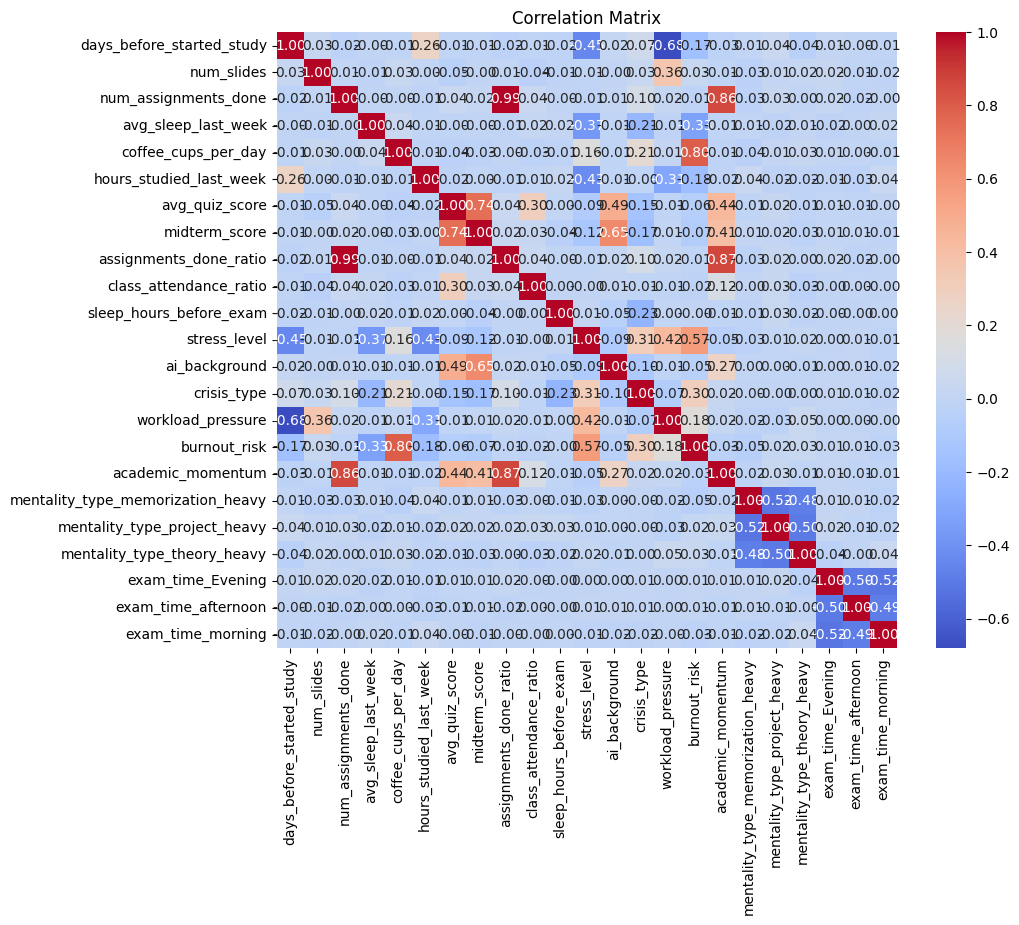

In [24]:
# F) Plot Correlation Matrix
plt.figure(figsize=(10, 8))
# Fix: numeric_only=True ensures we don't try to compute correlation on string columns
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Confusion Matrix Analysis 

The matrix validates that the new features are mathematically sound derivatives of the old ones, but it also proves that linear analysis is insufficient for the specific target variable (crisis_type), justifying the use of more complex classification models.

## 4. Train Test Split

In [25]:
# Prepare X and y
# Drop the original string target AND the encoded target column from X
X = df.drop(['crisis_type'], axis=1)
y_encoded = df['crisis_type']

# Split data into Train and Validation sets (75% Train, 25% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

print("Classes:", le.classes_)

Classes: ['Denial_mode' 'No_issue' 'panic_mode']


## 5-6. Training & Testing , Validation Classification Report

In [26]:

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)


y_pred = dt_model.predict(X_val)


print("--- Decision Tree Results (Depth 5) ---")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=le.classes_))


--- Decision Tree Results (Depth 5) ---
Accuracy: 0.9539551357733176

Classification Report:

              precision    recall  f1-score   support

 Denial_mode       0.86      0.99      0.92       199
    No_issue       0.99      0.93      0.96       340
  panic_mode       0.99      0.96      0.97       308

    accuracy                           0.95       847
   macro avg       0.95      0.96      0.95       847
weighted avg       0.96      0.95      0.95       847



**1. Metrics in Part 2 (Binary):**
* In Part 2, we had only two classes (Important vs. Spam).
* Metrics like `Precision`, `Recall`, and `F1-Score` are typically calculated with respect to a single "Positive" class (e.g., "Important"). We didn't necessarily need to average them; We just looked at how well the model found the "Important" emails.

**2. Metrics in Part 3 (Multi-class):**
* In Part 3, we have **three** classes: `No_issue`, `Panic_mode`, and `Denial_mode` .
* We cannot calculate a single "Precision" for the whole model directly. Instead, We must calculate precision for **each class separately** (e.g., Precision for Panic, Precision for Denial, etc.).
* **The "Difference":** The question asks for **Macro-averaged** metrics. This means We calculate the metrics for all 3 classes individually and then take the **simple average** of those three numbers.
    * *Macro-average* treats all classes as equally important, regardless of how many students are in each category (unlike *Weighted-average*, which cares about class size).

## 7. Plot The Tree 

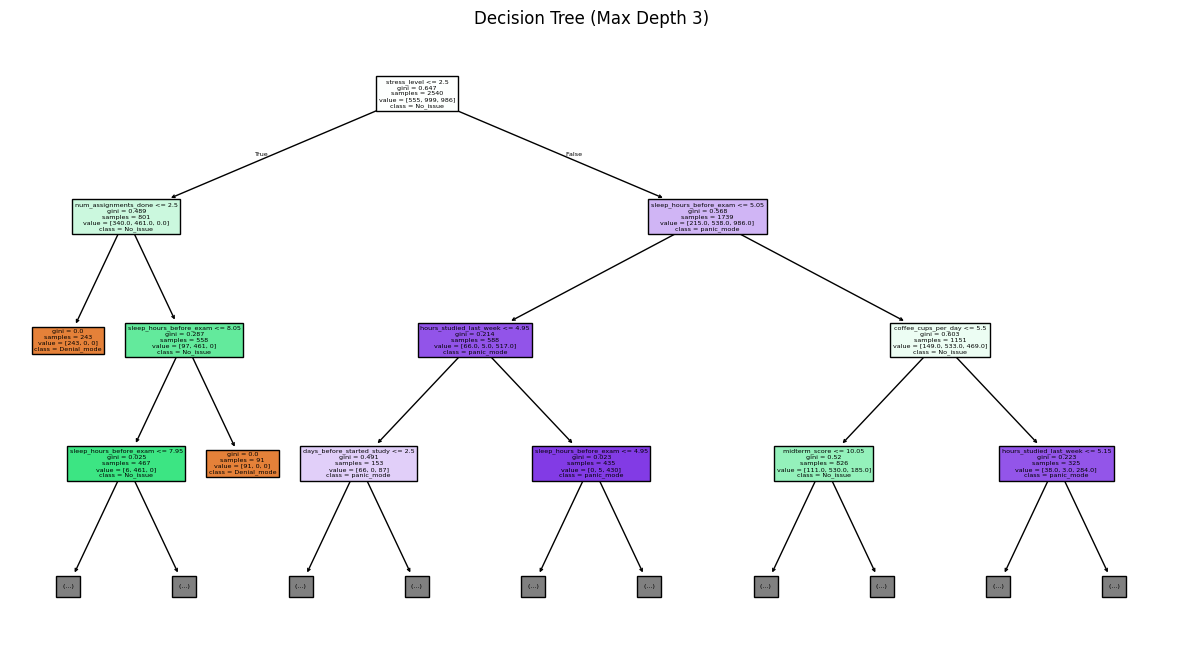

In [27]:
plt.figure(figsize=(15, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=le.classes_, filled=True, max_depth=3)
plt.title("Decision Tree (Max Depth 3)")
plt.show()

### Important Features 

C:\Users\user\AppData\Local\Temp\ipykernel_1960\1876543584.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


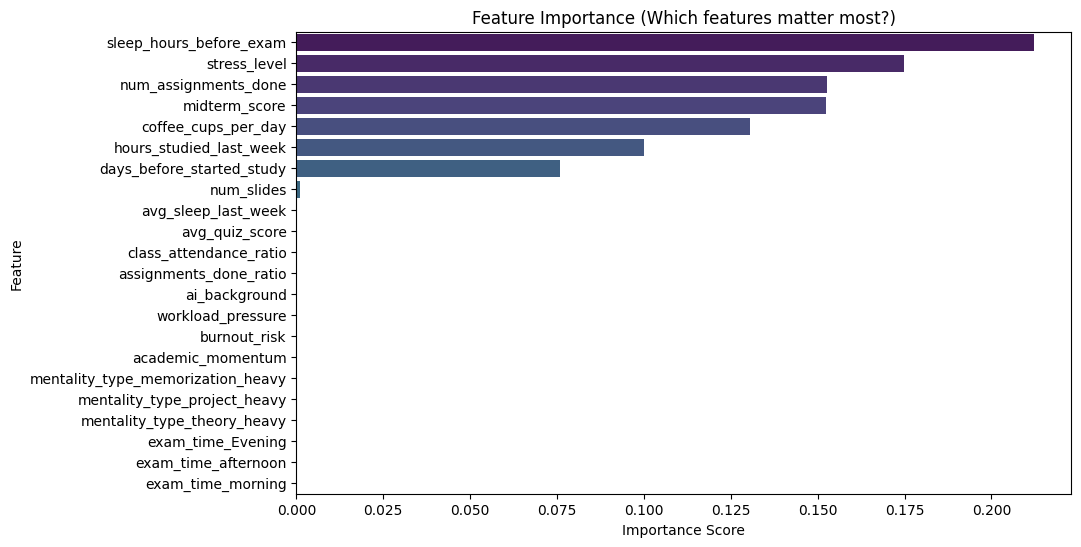

                    Feature  Importance
10  sleep_hours_before_exam    0.212399
11             stress_level    0.174834
2      num_assignments_done    0.152585
7             midterm_score    0.152539
4       coffee_cups_per_day    0.130595


In [28]:

importances = dt_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (Which features matter most?)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feat_imp_df.head(5))

## 8. Which features are getting mixed up ?! 

Since Denial_mode has the lowest Precision (0.82) and No_issue has the lowest Recall (0.87), we can conclude that the most significant confusion occurs between these two classes. Specifically, the model tends to misclassify students who actually have No_issue as being in Denial_mode

## After Meeting (un known number , I guess section 2 of part 3)

### 1. Creating a RandomForestClassifier

In [29]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


### 2. Fitting and Optimizing

In [30]:
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=5, cv=3, random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

print("\n--- Random Forest (Best Params) ---")
print(rf_search.best_params_)
print("Accuracy:", accuracy_score(y_val, rf_search.predict(X_val)))


--- Random Forest (Best Params) ---
{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
Accuracy: 0.9846517119244392


#### Multi-class Metrics 

In [31]:
y_pred_rf = rf_search.predict(X_val)
cm = confusion_matrix(y_val, y_pred)

print(classification_report(y_val, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

 Denial_mode       0.86      0.99      0.92       199
    No_issue       0.99      0.93      0.96       340
  panic_mode       0.99      0.96      0.97       308

    accuracy                           0.95       847
   macro avg       0.95      0.96      0.95       847
weighted avg       0.96      0.95      0.95       847



## 3-6. GradientBoostingClassifier

In [32]:
gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}
gb_search = GridSearchCV(gb, gb_params, cv=3, n_jobs=-1)
gb_search.fit(X_train, y_train)

print("\n--- Gradient Boosting (Best Params) ---")
print(gb_search.best_params_)

y_pred_gbc = rf_search.predict(X_val)
cm = confusion_matrix(y_pred_gbc, y_pred)

print(classification_report(y_val, y_pred, target_names=le.classes_))



--- Gradient Boosting (Best Params) ---
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
              precision    recall  f1-score   support

 Denial_mode       0.86      0.99      0.92       199
    No_issue       0.99      0.93      0.96       340
  panic_mode       0.99      0.96      0.97       308

    accuracy                           0.95       847
   macro avg       0.95      0.96      0.95       847
weighted avg       0.96      0.95      0.95       847



### 7. Why is One-Hot Encoding generally more suitable for Linear and Distance-Based models?

**1. Preventing False Ordinal Relationships**
Linear models (like Logistic Regression) and distance-based models (like KNN or SVM) interpret numerical values mathematically.
* If you use **Label Encoding** (e.g., `Theory`=0, `Project`=1, `Memorization`=2), the model assumes that:
    * `Memorization` (2) is "greater than" `Project` (1).
    * The "distance" between `Theory` and `Memorization` (2 - 0 = 2) is twice the distance between `Theory` and `Project` (1 - 0 = 1).
* For **Nominal** data (categories without order), this assumption is **false** and introduces noise, confusing the model. One-Hot Encoding treats all categories equally (0 or 1), preventing the model from learning incorrect patterns based on arbitrary number assignments.

**2. Geometry and Distance (Equidistance)**
In a multi-dimensional feature space, One-Hot Encoding ensures that the distance between any two distinct categories is **equal**.
* **Vector Example:**
    * Cat A: `[1, 0, 0]`
    * Cat B: `[0, 1, 0]`
    * Cat C: `[0, 0, 1]`
* The Euclidean distance between any pair is identical ($\sqrt{2}$). This is crucial for distance-based algorithms (like KNN) to treat all categories as equally distinct from one another.

**3. Independent Weights in Linear Models**
Linear models calculate output as $y = w \cdot x + b$.
* With **Label Encoding**, the model learns **one single weight** ($w$) for the column. It is forced to assume that as the category number increases (0 $\to$ 1 $\to$ 2), the target variable increases or decreases linearly.
* With **One-Hot Encoding**, the model learns a **separate weight** for each category (e.g., $w_{theory}$, $w_{project}$). This allows the model to capture the unique impact of *each* specific category on the prediction independently.

## After Finding The problem (probably section 3)

### 1. Creating a binary matrix

In [33]:
y_train_denial = (y_train == 0).astype(int)
y_train_no_issue = (y_train == 1).astype(int)
y_train_panic = (y_train == 2).astype(int)

### 2. Train 3 separate binary models

In [34]:

clf_denial = DecisionTreeClassifier(random_state=42).fit(X_train, y_train_denial)
clf_no_issue = DecisionTreeClassifier(random_state=42).fit(X_train, y_train_no_issue)
clf_panic = DecisionTreeClassifier(random_state=42).fit(X_train, y_train_panic)


### 3. Predict probabilities on Validation data

In [35]:
prob_denial = clf_denial.predict_proba(X_val)[:, 1]
prob_no_issue = clf_no_issue.predict_proba(X_val)[:, 1]
prob_panic = clf_panic.predict_proba(X_val)[:, 1]


### 4. Validating and CM

In [36]:
probs_combined = np.vstack([prob_denial, prob_no_issue, prob_panic]).T
y_pred_ovr = np.argmax(probs_combined, axis=1)

print("OvR Accuracy:", accuracy_score(y_val, y_pred_ovr))
print(classification_report(y_val, y_pred_ovr, target_names=le.classes_))

OvR Accuracy: 0.9858323494687131
              precision    recall  f1-score   support

 Denial_mode       0.97      0.99      0.98       199
    No_issue       0.99      0.98      0.99       340
  panic_mode       0.99      0.98      0.99       308

    accuracy                           0.99       847
   macro avg       0.98      0.99      0.99       847
weighted avg       0.99      0.99      0.99       847



### Comparing

Compared to the previous part, the accuracy is higher!

### 5. Why does label encoding sometimes become problematic to use for categorical features in machine learning?

The problem arises because some algorithms may interpret these integers as having an ordinal relationship (e.g., 0 < 1 < 2), even when no natural order exists between the categories. This can mislead models like linear regression or logistic regression. LabelEncoding is fine for tree-based models (like Decision Trees or Random Forests) that do not assume order, but caution is needed for algorithms sensitive to numeric order.

### 6. Explain the difference between using LabelEncoding and One-Hot labels, and in which cases One-Hot encoding should be used, for example in one-vs-rest classification.

LabelEncoding converts categorical labels into integers (e.g., A → 0, B → 1, C → 2). It is simple and efficient, but it introduces an artificial ordinal relationship between categories, which can mislead some algorithms, especially those that assume numerical order (like linear models).

One-Hot Encoding, on the other hand, converts each category into a separate binary feature (e.g., A → [1,0,0], B → [0,1,0], C → [0,0,1]). This avoids implying any order between categories and is safer for algorithms that treat input numerically.

Use case: One-Hot Encoding is especially recommended for multiclass problems when using classifiers like Logistic Regression, SVM, or one-vs-rest schemes, where you don’t want the model to assume any ordinal relationship between categories.

# Part 4

## 1. Load and Pre Process 

In [37]:
df = pd.read_csv("DATA/Section4/part4_dataset.csv")
df['midterm_score'] = df['midterm_score'].fillna(df['midterm_score'].median())
df['stress_level'] = df['stress_level'].fillna(df['stress_level'].median())
df['midterm_score'] = df['midterm_score'].clip(0, 20)
df['hours_studied_last_week'] = df['hours_studied_last_week'].clip(upper=100)
df['coffee_cups_per_day'] = df['coffee_cups_per_day'].clip(upper=10)

# 1. Workload Pressure
df['workload_pressure'] = df['num_slides'] / (df['days_before_started_study'] + 1)

# 2. Burnout Risk Index
df['burnout_risk'] = (df['coffee_cups_per_day'] * df['stress_level']) / (df['avg_sleep_last_week'] + 1)

# 3. Academic Momentum
df['academic_momentum'] = ((df['midterm_score'] + df['avg_quiz_score']) / 2) * df['assignments_done_ratio']

ai_mapping = {'none': 0, 'basic': 1, 'strong': 2}
df['ai_background'] = df['ai_background'].map(ai_mapping)

# 2. & 3. One-Hot Encoding for 'mentality_type' and 'exam_time'
df = pd.get_dummies(df, columns=['mentality_type', 'exam_time'], dtype=int)

# 4. Label Encoding for 'crisis_type' (Target)
le = LabelEncoder()
df['crisis_type'] = le.fit_transform(df['crisis_type'])


## 1. Training Models

In [38]:
y = df['final_exam_score']
X = df.drop(['final_exam_score', 'crisis_type'], axis=1)

# Final check for NaNs before modeling
X = X.fillna(0)

# Split Data (75% Train, 25% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}


## 2. Validation Custom metrics  

In [39]:
def custom_mse(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    errors = y_true - y_pred
    return np.mean(errors ** 2)

def custom_mae(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    errors = np.abs(y_true - y_pred)
    return np.mean(errors)

def custom_r2(y_true, y_pred):
   
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    if ss_tot == 0:
        return 0.0
        
    return 1 - (ss_res / ss_tot)


print(f"{'Model':<20} | {'MSE':<10} | {'MAE':<10} | {'R2 Score':<10}")
print("-" * 60)

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate metrics manually
    mse = custom_mse(y_val, y_pred)
    mae = custom_mae(y_val, y_pred)
    r2 = custom_r2(y_val, y_pred)
    
    print(f"{name:<20} | {mse:<10.4f} | {mae:<10.4f} | {r2:<10.4f}")

Model                | MSE        | MAE        | R2 Score  
------------------------------------------------------------
Decision Tree        | 15.1696    | 2.7926     | 0.2439    
Random Forest        | 7.6098     | 2.0117     | 0.6207    
XGBoost              | 8.0167     | 2.0690     | 0.6004    


## 3. Explaining The Metrics 

The previous ones were for classification. These are for regression

a. **MSE (Mean Squared Error)** – measures the average of the squared differences between predicted and actual values. Mainly used for regression.

b. **MAE (Mean Absolute Error)** – measures the average of the absolute differences between predicted and actual values. Less sensitive to outliers than MSE.

c. **R² Score** – indicates the proportion of variance in the dependent variable that is predictable from the independent variables. Ranges from 0 to 1 (or negative if the model is worse than predicting the mean).




**For classification metrics:**

i. **Macro-averaged Precision, Recall, F1** – averages the precision, recall, and F1 scores across all classes equally, ignoring class imbalance.

ii. **Confusion Matrix** – a table showing counts of true positives, true negatives, false positives, and false negatives for each class. Useful to see where the model makes mistakes.




## Bias Variance Part : 

### 1. x_star

In [40]:
x_star = X_val.iloc[[0]]
true_y = y_val.iloc[0]

# Dictionary to store predictions for each model
predictions = {k: [] for k in models.keys()}
n_iterations = 100

print(f"\nRunning Bias-Variance Experiment on x_star (True y = {true_y:.2f})...")



Running Bias-Variance Experiment on x_star (True y = 12.40)...


### 2. Loop 

In [41]:
# 2. Loop for sampling and training
for i in range(100):
    # a. Randomly select 30% of the ORIGINAL data (simulating different training sets)
    sample_indices = np.random.choice(X.index, size=int(0.3 * len(X)), replace=False)
    X_sample = X.loc[sample_indices]
    y_sample = y.loc[sample_indices]
    
    # b. Train models on the sample
    for name, model_cls in [("Decision Tree", DecisionTreeRegressor), 
                            ("Random Forest", RandomForestRegressor), 
                            ("XGBoost", XGBRegressor)]:
        
        # Create a new instance each time
        model = model_cls(random_state=None) # No random_state here to allow variance from data
        model.fit(X_sample, y_sample)
        
        # c. Predict on x_star and store
        pred = model.predict(x_star)[0]
        predictions[name].append(pred)

### 3. Plotting 

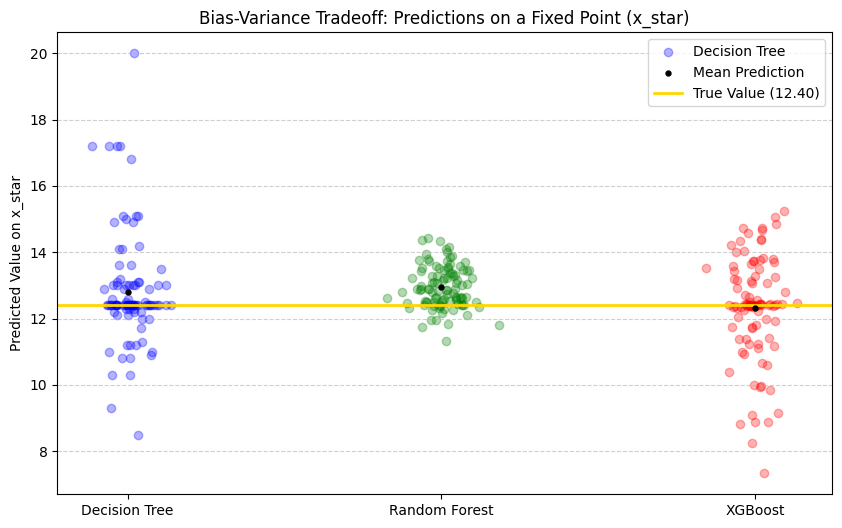

In [42]:

plt.figure(figsize=(10, 6))
model_names = list(models.keys())
x_positions = range(len(model_names))
colors = ['blue', 'green', 'red']
for idx, name in enumerate(model_names):
    preds = predictions[name]
    
    # Plot all predictions as scatter points
    # Add small jitter to x-axis for better visibility
    x_jitter = np.random.normal(idx, 0.05, size=len(preds))
    plt.scatter(x_jitter, preds, alpha=0.3, color=colors[idx], label=name if idx==0 else "")
    
    # Plot the MEAN prediction (to visualize Bias)
    mean_pred = np.mean(preds)
    plt.scatter(idx, mean_pred, color='black', marker='.', s=50, zorder=10, label='Mean Prediction' if idx==0 else "")

# d. Plot the True Value line (Bullseye)
plt.axhline(y=true_y, color='gold', linestyle='-', linewidth=2, label=f'True Value ({true_y:.2f})')

# Formatting the plot
plt.xticks(x_positions, model_names)
plt.ylabel(f'Predicted Value on x_star')
plt.title('Bias-Variance Tradeoff: Predictions on a Fixed Point (x_star)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 5. Compare the predictions of the models with the true value `y_true` and explain which model has higher bias and which has higher variance.


* **Decision Tree (blue points):**

  * The predictions are widely spread around the true value.
  * This indicates **high variance** because different decision trees trained on different data points vary a lot.
  * The mean prediction is roughly near the true value, so **bias is low**.

* **Random Forest (green points):**

  * Predictions are tightly clustered around the true value.
  * This indicates **low variance**, as averaging multiple trees reduces the spread.
  * The mean prediction is close to the true value, so **bias is also low**.

* **XGBoost (red points):**

  * Predictions are somewhat spread, but not as much as a single decision tree.
  * Shows **moderate variance**.
  * The mean prediction is very close to the true value, so **bias is low**.



### 6. What is the random variable in this experiment?

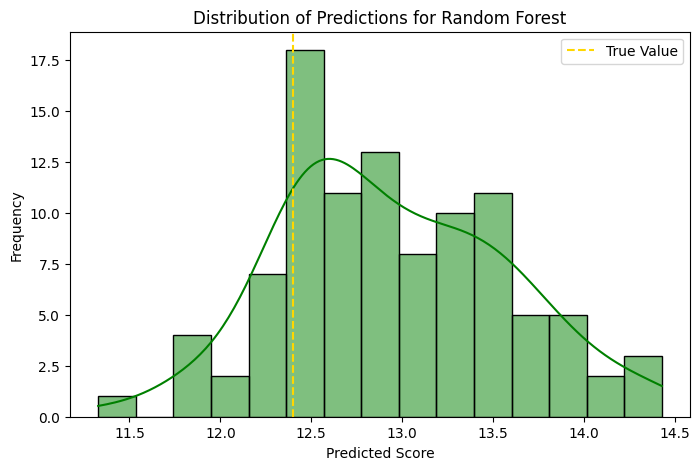

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Let's look at the distribution for Random Forest (usually the most Normal)
model_name = "Random Forest" 
# or try "Decision Tree" or "XGBoost"

plt.figure(figsize=(8, 5))
# Plot histogram with a Kernel Density Estimate (KDE) line
sns.histplot(predictions[model_name], kde=True, color='green', bins=15)

plt.title(f'Distribution of Predictions for {model_name}')
plt.xlabel('Predicted Score')
plt.ylabel('Frequency')
plt.axvline(x=true_y, color='gold', linestyle='--', label="True Value")
plt.legend()
plt.show()

This, does look like the normal distribution, but we have to test it. 


In [44]:
from scipy.stats import shapiro

print(f"{'Model':<20} | {'W-Statistic':<12} | {'P-Value':<12} | {'Result'}")
print("-" * 65)

for name, preds in predictions.items():
    # Perform Shapiro-Wilk test
    stat, p = shapiro(preds)
    
    # Interpret result
    alpha = 0.05
    is_normal = "Normal" if p > alpha else "Not Normal"
    
    print(f"{name:<20} | {stat:<12.4f} | {p:<12.4f} | {is_normal}")

Model                | W-Statistic  | P-Value      | Result
-----------------------------------------------------------------
Decision Tree        | 0.8075       | 0.0000       | Not Normal
Random Forest        | 0.9845       | 0.2904       | Normal
XGBoost              | 0.9381       | 0.0001       | Not Normal


In [48]:

# --- PART 1 TEST PREDICTION ---
print("--- Generating Submission for Section 1 - Part 1 ---")
try:
    # Load test data
    df_test_p1_1 = pd.read_csv("DATA/Section1/Part1/s1_part1_test.csv")
    df_test_p1_1.columns = df_test_p1_1.columns.str.strip()

    # Preprocessing
    skill_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    if 'prog_skill' in df_test_p1_1.columns:
        df_test_p1_1['prog_skill'] = df_test_p1_1['prog_skill'].map(skill_mapping)
    
    df_test_p1_1 = df_test_p1_1.fillna(0)

    # Select features
    feature_cols_1 = ['group_size', 'meetings_per_week', 'prog_skill'] 
    X_test_1 = df_test_p1_1[feature_cols_1].values

    # Predict and save
    pred_p1_1 = best_model.predict(X_test_1)
    df_test_p1_1['Is_finished'] = pred_p1_1
    df_test_p1_1.to_csv("section1_part1_submission.csv", index=False)
    print("✓ Success: 'section1_part1_submission.csv' saved.")

except Exception as e:
    print(f"x Error in Part 1: {e}")

# Generate Part 2 Submission
print("\n--- Generating Submission for Section 1 - Part 2 (New Feature) ---")
try:
    # Load test data
    df_test_p1_2 = pd.read_csv("DATA/Section1/Part2/s1_part2_test.csv")
    df_test_p1_2.columns = df_test_p1_2.columns.str.strip()

    # Preprocessing
    if 'prog_skill' in df_test_p1_2.columns:
        df_test_p1_2['prog_skill'] = df_test_p1_2['prog_skill'].map(skill_mapping)
    
    df_test_p1_2 = df_test_p1_2.fillna(0)

    # Select features including new one
    feature_cols_2 = ['group_size', 'meetings_per_week', 'prog_skill', 'avg_previous_grade']
    X_test_2 = df_test_p1_2[feature_cols_2].values

    # Predict and save
    pred_p1_2 = model_deep_new.predict(X_test_2)
    df_test_p1_2['Is_finished'] = pred_p1_2
    df_test_p1_2.to_csv("section1_part2_submission.csv", index=False)
    print("✓ Success: 'section1_part2_submission.csv' saved.")

except Exception as e:
    print(f"x Error in Part 2: {e}")

--- Generating Submission for Section 1 - Part 1 ---
✓ Success: 'section1_part1_submission.csv' saved.

--- Generating Submission for Section 1 - Part 2 (New Feature) ---
✓ Success: 'section1_part2_submission.csv' saved.


In [49]:
# --- PART 2 TEST PREDICTION ---

# 1. Load the Test Data
df_test_p2 = pd.read_csv("DATA/Section2/part2_test.csv")

# 2. Preprocess: Clean the text using  existing function
df_test_p2['clean_text'] = df_test_p2['message_body'].apply(clean_text)

# 3. Feature Extraction: Transform using the ALREADY FITTED vectorizer
# Note: We use .transform(), NOT .fit_transform()
X_test_p2 = vectorizer_binary.transform(df_test_p2['clean_text'])

# 4. Run Prediction
# We use the trained BernoulliNB model (bnb_model)
pred_p2 = bnb_model.predict(X_test_p2)

# 5. Save Results
df_test_p2['label'] = pred_p2
df_test_p2.to_csv("part2_submission.csv", index=False)

print("Part 2 predictions saved. Sample:")
print(df_test_p2[['message_body', 'label']].head())

Part 2 predictions saved. Sample:
                                        message_body  label
0         Office hours are moved to Tuesday morning.      1
1   Registration for summer school starts next week.      1
2                  Book your hotel now and save big.      0
3  Quiz 4 will cover Neural Networks and Deep Lea...      1
4  Please follow the IEEE format for your project...      1


In [50]:
# --- PART 3 TEST PREDICTION ---

# 1. Load Data
df_test_p3 = pd.read_csv("DATA/Section3/part3_test.csv")

# 2. Handle Missing Values

#  use X_train's medians)
df_test_p3['midterm_score'] = df_test_p3['midterm_score'].fillna(df['midterm_score'].median()) 
df_test_p3['stress_level'] = df_test_p3['stress_level'].fillna(df['stress_level'].median())

# 3. Clip Values (Same as training)
df_test_p3['midterm_score'] = df_test_p3['midterm_score'].clip(0, 20)
df_test_p3['hours_studied_last_week'] = df_test_p3['hours_studied_last_week'].clip(upper=100)
df_test_p3['coffee_cups_per_day'] = df_test_p3['coffee_cups_per_day'].clip(upper=10)

# 4. Re-create New Features
df_test_p3['workload_pressure'] = df_test_p3['num_slides'] / (df_test_p3['days_before_started_study'] + 1)
df_test_p3['burnout_risk'] = (df_test_p3['coffee_cups_per_day'] * df_test_p3['stress_level']) / (df_test_p3['avg_sleep_last_week'] + 1)
df_test_p3['academic_momentum'] = ((df_test_p3['midterm_score'] + df_test_p3['avg_quiz_score']) / 2) * df_test_p3['assignments_done_ratio']

# 5. Encoding
# Map Ordinal
ai_mapping = {'none': 0, 'basic': 1, 'strong': 2}
df_test_p3['ai_background'] = df_test_p3['ai_background'].map(ai_mapping)

# One-Hot Encoding
df_test_p3 = pd.get_dummies(df_test_p3, columns=['mentality_type', 'exam_time'], dtype=int)

# 6. CRITICAL STEP: Align Columns
# 'X' here refers to your training feature matrix from Part 3
missing_cols = set(X.columns) - set(df_test_p3.columns)
for c in missing_cols:
    df_test_p3[c] = 0 # Add missing columns with 0

# Reorder columns to match training data exactly
df_test_p3 = df_test_p3[X.columns]
# Handle any NaN introduced by mapping
df_test_p3 = df_test_p3.fillna(0) 

# 7. Predict
# Using our best model (e.g., rf_search or dt_model)
pred_p3_encoded = rf_search.predict(df_test_p3)

# 8. Convert back to String Labels 
pred_p3_labels = le.inverse_transform(pred_p3_encoded)

# 9. Save
df_test_p3_save = pd.read_csv("DATA/Section3/part3_test.csv") # Reload to keep original clean structure
df_test_p3_save['label'] = pred_p3_labels
df_test_p3_save.to_csv("part3_submission.csv", index=False)

print("Part 3 predictions saved. Sample:")
print(df_test_p3_save['label'].head())

Part 3 predictions saved. Sample:
0       No_issue
1     panic_mode
2    Denial_mode
3    Denial_mode
4       No_issue
Name: label, dtype: object


In [51]:
# --- PART 4 TEST PREDICTION ---

# 1. Load Data
df_test_p4 = pd.read_csv("DATA/Section4/part4_test.csv")

# 2. Preprocessing Pipeline (Copy-Paste logic from Part 3)
df_test_p4['midterm_score'] = df_test_p4['midterm_score'].fillna(df['midterm_score'].median()) 
df_test_p4['stress_level'] = df_test_p4['stress_level'].fillna(df['stress_level'].median())
df_test_p4['midterm_score'] = df_test_p4['midterm_score'].clip(0, 20)
df_test_p4['hours_studied_last_week'] = df_test_p4['hours_studied_last_week'].clip(upper=100)
df_test_p4['coffee_cups_per_day'] = df_test_p4['coffee_cups_per_day'].clip(upper=10)

df_test_p4['workload_pressure'] = df_test_p4['num_slides'] / (df_test_p4['days_before_started_study'] + 1)
df_test_p4['burnout_risk'] = (df_test_p4['coffee_cups_per_day'] * df_test_p4['stress_level']) / (df_test_p4['avg_sleep_last_week'] + 1)
df_test_p4['academic_momentum'] = ((df_test_p4['midterm_score'] + df_test_p4['avg_quiz_score']) / 2) * df_test_p4['assignments_done_ratio']

ai_mapping = {'none': 0, 'basic': 1, 'strong': 2}
df_test_p4['ai_background'] = df_test_p4['ai_background'].map(ai_mapping)
df_test_p4 = pd.get_dummies(df_test_p4, columns=['mentality_type', 'exam_time'], dtype=int)

# 3. Align Columns (Using X from Part 4 training)
#'X' here is the feature set you used for Part 4 training
missing_cols_p4 = set(X_train.columns) - set(df_test_p4.columns)
for c in missing_cols_p4:
    df_test_p4[c] = 0
df_test_p4 = df_test_p4[X_train.columns]
df_test_p4 = df_test_p4.fillna(0)

# 4. Predict
# Use chosen regression model here random Forest
pred_p4 = models['Random Forest'].predict(df_test_p4)

# 5. Save
df_test_p4_save = pd.read_csv("DATA/Section4/part4_test.csv")
df_test_p4_save['label'] = pred_p4 # Predicted Final Score
df_test_p4_save.to_csv("part4_submission.csv", index=False)

print("Part 4 predictions saved.")

Part 4 predictions saved.
